In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt

In [3]:
Ps = np.array([[0, 0], [1, 1], [2, -1], [3, 0]])

**Задача** вычислить касательные векторы для $N$ фрагментов кубического сплайна.

- Для этого должно быть дано $N+1$ точек $P_i$.
- Формируем трехдиагональную матрицу $A$ размером $(N+1)\times(N+1)$.
- Вектор $\mathbf{b}$ из $N+1$ элементов правой часть системы.

\begin{equation*}
    \underbrace{
    \begin{bmatrix}
      1 & 0 & 0 & \ldots & 0 & 0 \\
      t_2 & 2(t_1 + t_2) & t_1 & \ldots & 0 & 0\\ 
      0 & t_3 & 2(t_2 + t_3) & \ldots & 0 & 0\\
      0 & 0 & t_4 & \ldots & 0 & 0\\
      0 & 0 & 0 & \ldots & 0 & 0\\
      \vdots & \vdots & \vdots & \ddots & \vdots & \vdots\\
      0 & 0 & 0 & \ldots & 0 & 0\\
      0 & 0 & 0 & \ldots & t_{N-2} & 0\\
      0 & 0 & 0 & \ldots & 2(t_{N-1} + t_{N}) & t_{N-1}\\
      0 & 0 & 0 & \ldots & 0 & 1
    \end{bmatrix}
    }_{A}
    \begin{bmatrix}
      \dot{\mathbf{p}}_0\\
      \dot{\mathbf{p}}_1\\
      \dot{\mathbf{p}}_2\\
      \dot{\mathbf{p}}_3\\
      \dot{\mathbf{p}}_4\\
      \vdots\\
      \dot{\mathbf{p}}_{N-3}\\
      \dot{\mathbf{p}}_{N-2}\\
      \dot{\mathbf{p}}_{N-1}\\
      \dot{\mathbf{p}}_N\\
    \end{bmatrix}
    =
    \overbrace{
    \begin{bmatrix}
      \dot{\mathbf{p}}_0\\
      \dfrac{3\big( t^2_1 (\mathbf{p}_2 - \mathbf{p}_1) + t^2_2(\mathbf{p}_1 - \mathbf{p}_0) \big)}{t_1t_2}\\
      \dfrac{3\big( t^2_2 (\mathbf{p}_3 - \mathbf{p}_2) + t^2_3(\mathbf{p}_2 - \mathbf{p}_1) \big)}{t_2t_3}\\
      \dfrac{3\big( t^2_3 (\mathbf{p}_4 - \mathbf{p}_3) + t^2_4(\mathbf{p}_3 - \mathbf{p}_2) \big)}{t_3t_4}\\
      \vdots \\
      \dfrac{3\big( t^2_{N-2} (\mathbf{p}_{N-1} - \mathbf{p}_{N-2}) + t^2_{N-1}(\mathbf{p}_{N-2} - \mathbf{p}_{N-3}) \big)}{t_{N-2}t_{N-1}}\\
      \dfrac{3\big( t^2_{N-1} (\mathbf{p}_N - \mathbf{p}_{N-1}) + t^2_N(\mathbf{p}_{N-1} - \mathbf{p}_{N-2}) \Big)}{t_{N-1}t_N}\\
      \dot{\mathbf{p}}_N
    \end{bmatrix}
    }^{\mathbf{b}}
\end{equation*}

\begin{equation*}
    \begin{aligned}
        &b_{0} = \dot{\mathbf{p}}_0 \approx \mathbf{p}_1 - \mathbf{p}_{0},\\
        &b_{i} = \dfrac{3}{t_i t_{i+1}}\big( t^2_i(\mathbf{p}_{i+1} - \mathbf{p}_i) + t^2_{i+1}(\mathbf{p}_i - \mathbf{p}_{i-1}) \big), i=1,2,\ldots,(N-1)\\
        &b_{N} = \dot{\mathbf{p}}_N  \approx \mathbf{p}_N - \mathbf{p}_{N-1}.
    \end{aligned}
\end{equation*}

In [4]:
def chord_approximation(Ps):
    "Вычисление параметров [t_i] согласно хордовой аппроксимации"
    return np.linalg.norm(Ps[1:] - Ps[:-1], axis=1)


def normal_approximation(Ps):
    "Вычисление параметров [t_i] согласно нормальной аппроксимации"
    return np.ones(Ps.shape[0]-1)

def calc_tangent_vectors(Ps):
    # Сформируем диагонали трехдиагональной матрицы
    N = Ps.shape[0] - 1
    # три диагонали
    d1 = np.empty(N)
    d2 = np.empty(N+1)
    d3 = np.empty(N)
    b = np.empty(shape=(N+1, 2))
    T = chord_approximation(Ps)
    
    d2[0] = 1
    d2[1:-1] = 2*(T[:-1] + T[1:])
    d2[-1] = 1
    
    d1[0] = 0
    d1[1:] = T[:-1]
    
    d3[0:-1] = T[1:]
    d3[-1] = 0
    
    b[0] = Ps[1] - Ps[0]
    b[1:-1] = 3 * ((Ps[2:] - Ps[1:-1]) * T[:-1, np.newaxis]**2 + (Ps[1:-1] - Ps[0:-2]) * T[1:, np.newaxis]**2 ) / (T[:-1]*T[1:])[:, np.newaxis]
    b[-1] = Ps[-1] - Ps[-2]
    A = np.diag(d1, 1) + np.diag(d2, 0) + np.diag(d3, -1)
    return np.linalg.solve(A, b)

# Весовые функции
def F1(τ, ti): return 2*τ**3 - 3*τ**2 + 1

def F2(τ, ti): return -2*τ**3 + 3*τ**2

def F3(τ, ti): return τ * (τ**2 - 2*τ  + 1) * ti

def F4(τ, ti): return τ * (τ**2 - τ) * ti


def cspline_segment(τ, ti, p0, p1, v0, v1):
    "Один сегмент сплайна"
    res = p0 * F1(τ, ti)[:, np.newaxis] + p1 * F2(τ, ti)[:, np.newaxis]
    res += v0 * F3(τ, ti)[:, np.newaxis] + v1 * F4(τ, ti)[:, np.newaxis]
    return  res

def cspline(τ, Ps):
    "Все сегменты сплайна"
    Vs = calc_tangent_vectors(Ps)
    T = chord_approximation(Ps)
    return np.row_stack([cspline_segment(τ, ti, p0, p1, v0, v1) 
                         for (ti, p0, p1, v0, v1) in zip(T, Ps[:-1], Ps[1:], Vs[:-1], Vs[1:])])

In [5]:
τ = np.array([1/3, 2/3])
τ = np.linspace(0, 1, 30)
X, Y = cspline(τ, Ps).T

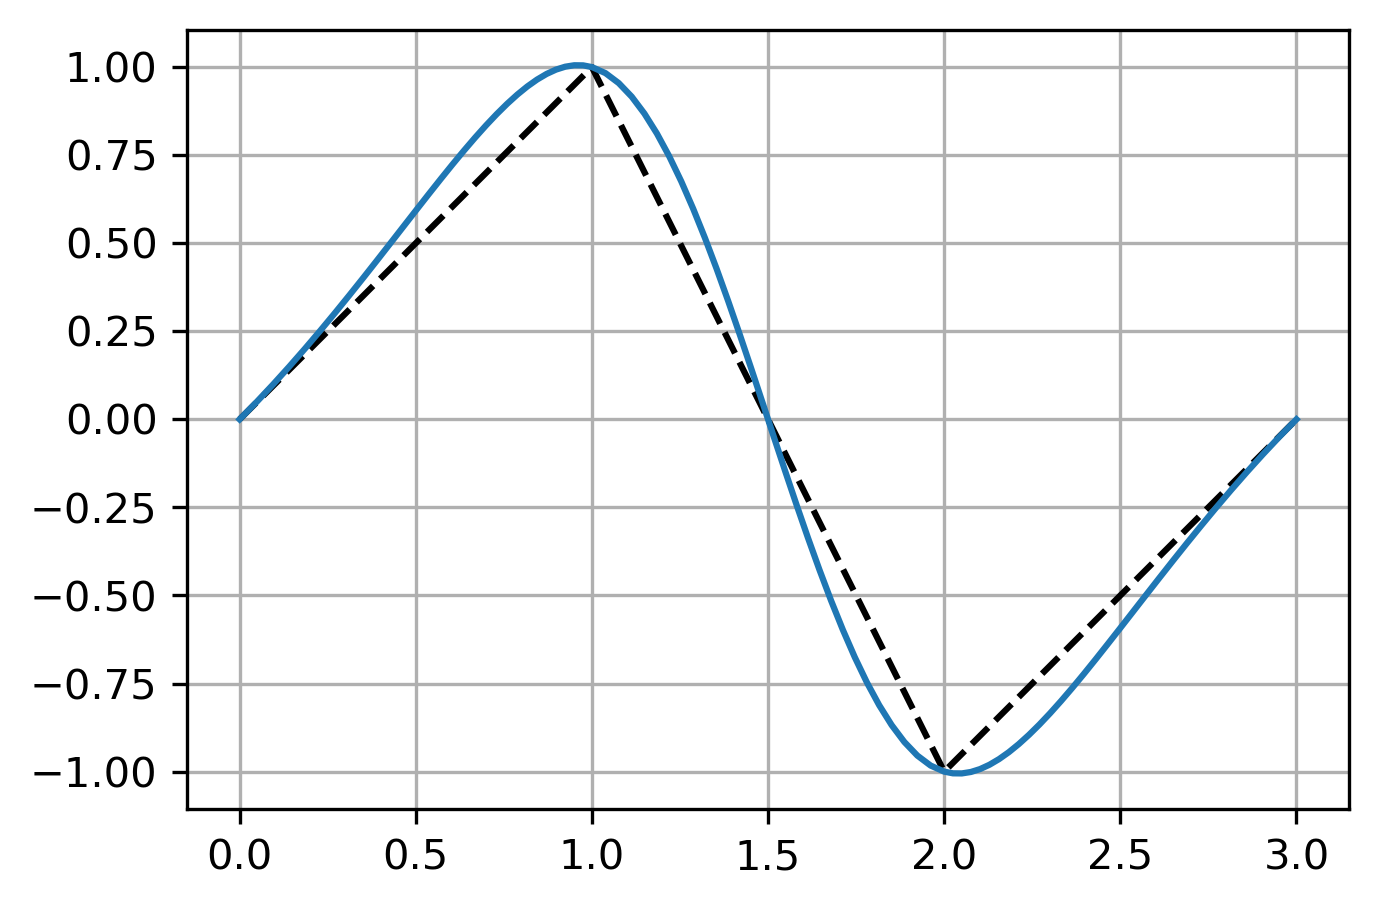

In [6]:
fig01 = plt.figure(num=1, figsize=(5, 5), dpi=300)
ax01 = fig01.add_subplot(1, 1, 1)
ax01.set_aspect('equal')
ax01.grid(True)

ax01.plot(*Ps.T, c='k', ls='--')
ax01.plot(X, Y)